# Man, Don't Get Angry - Board Game Detection

Jakub Laskowski (160287), Jakub Górniak (160326)

This notebook has the whole pipeline that takes a video of the board game
*Man, Don't Get Angry* and detects the state of the game frame by frame - the
board, the pawns, the die, the coin tokens and the events that come out of them.

Sections:

1. Setup and imports
2. Configuration - colours, board layout, game constants
3. Board detection - `BoardDetector`
4. Dice detection - `DiceDetector`
5. Pawn detection and tracking - `PieceTracker`
6. Token detection - `TokenTracker`
7. Game state and events - `GameStateManager`
8. Visualization - `Visualizer`
9. Putting it together - `VideoDetector`
10. Running it on videos

Run the cells from top to bottom. The last cell goes through every video in
`videos/` and writes the annotated result to `output/`.

## 1. Setup and imports

The usual numpy/matplotlib/OpenCV imports plus the matplotlib config for showing
things inline.

In [ ]:
import os
import time
import uuid
from collections import Counter, defaultdict, deque
from typing import ClassVar

import cv2
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

%matplotlib inline
plt.rcParams['figure.figsize'] = [14, 8]

## 2. Configuration

`DetectionConfig` keeps all the constants in one place:

- game states and their order (`GAME_STARTING` -> `IN_PROGRESS` -> `FINISHED`)
- `COLOR_RANGES` - HSV ranges for each player colour. There are separate top and
  side variants because of the glare when the board is filmed at an angle.
- `SPATIAL_LAYOUTS` - for each corner of the board, the grid coordinates of the
  home base, the finish lane, the ROI and the start tile.

In [ ]:
class DetectionConfig:
    """Game states, HSV ranges for the colours and the board layout per corner."""

    GAME_STARTING = "GAME_STARTING"
    GAME_IN_PROGRESS = "IN_PROGRESS"
    GAME_FINISHED = "FINISHED"
    STATE_ORDER: ClassVar[dict] = {"GAME_STARTING": 0, "IN_PROGRESS": 1, "FINISHED": 2}

    BASE_COLORS: ClassVar[set] = {'yellow', 'green', 'blue', 'pink'}

    COLOR_RANGES: ClassVar[dict] = {
        'yellow': {'lower': np.array([15, 110, 80]), 'upper': np.array([45, 255, 255]), 'bgr': (0, 255, 255)},
        'yellow_side': {'lower': np.array([10, 150, 165]), 'upper': np.array([30, 255, 255]), 'bgr': (0, 255, 255)},
        # top view often gets glare, so we allow lower saturation/higher brightness
        'yellow_top':  {'lower': np.array([15, 110, 80]), 'upper': np.array([45, 255, 255]), 'bgr': (0, 255, 255)},
        # 'green': {'lower': np.array([35, 40, 40]), 'upper': np.array([85, 255, 255]), 'bgr': (0, 255, 0)},
        'green': {'lower': np.array([50, 40, 40]), 'upper': np.array([85, 255, 255]), 'bgr': (0, 255, 0)},
        'blue': {'lower': np.array([85, 50, 50]), 'upper': np.array([135, 255, 255]), 'bgr': (255, 0, 0)},
        'pink': {'lower': np.array([140, 120, 120]), 'upper': np.array([180, 255, 255]), 'bgr': (0, 0, 255)}
    }

    SPATIAL_LAYOUTS: ClassVar[dict] = {
        'TOP_LEFT': {
            'home_coords': [(0, 0), (0, 1), (1, 0), (1, 1)],
            'finish_coords': [(5, 1), (5, 2), (5, 3), (5, 4), (5, 5)],
            'roi_slice': (0, 2, 0, 2),
            'start_tile': (4, 0)
        },
        'TOP_RIGHT': {
            'home_coords': [(0, 9), (0, 10), (1, 9), (1, 10)],
            'finish_coords': [(1, 5), (2, 5), (3, 5), (4, 5), (5, 5)],
            'roi_slice': (0, 2, 9, 11),
            'start_tile': (0, 6)
        },
        'BOTTOM_LEFT': {
            'home_coords': [(9, 0), (9, 1), (10, 0), (10, 1)],
            'finish_coords': [(9, 5), (8, 5), (7, 5), (6, 5), (5, 5)],
            'roi_slice': (9, 11, 0, 2),
            'start_tile': (10, 4)
        },
        'BOTTOM_RIGHT': {
            'home_coords': [(9, 9), (9, 10), (10, 9), (10, 10)],
            'finish_coords': [(5, 9), (5, 8), (5, 7), (5, 6), (5, 5)],
            'roi_slice': (9, 11, 9, 11),
            'start_tile': (6, 10)
        }
    }

## 3. Board detection

`BoardDetector` finds the board and turns it into a stable grid:

1. Contours - we try three binarisations (Otsu, fixed, adaptive) and keep the
   biggest 4-sided contour as the board.
2. Stabilisation - the corners are averaged over a few frames so the board does
   not jump around, and if the detection fails for a moment (someone's hand over
   the board) we reuse the last one.
3. Warp - perspective transform to a top-down square.
4. Grid - the grid lines come from the peaks of the projections along both axes,
   and the four corners are matched to the player colours to get the zone map.

In [ ]:
class BoardDetector:
    """Finds the board, keeps it stable between frames and builds the grid."""

    def __init__(self, board_size=1000, stability_frames=30, corner_threshold=50):
        # basic settings
        self.board_size = board_size
        self.corner_thresh = corner_threshold
        self.max_missed = 60

        # lists for smoothing
        self.history = deque(maxlen=stability_frames)
        self.avg_corners = None
        self.M = None
        self.M_inv = None
        self.missed_count = 0

        # grid stuff
        self.last_grid_corners = None
        self.grid_x = None
        self.grid_y = None
        self.grid_move_limit = 20.0

        # colors and zones
        self.zones_ready = False
        self.homes = {}
        self.finishes = {}
        self.starts = {}
        self.quad_colors = {}

    def reset(self):
        """Clear all per-video state so the detector can be reused."""
        self.history.clear()
        self.avg_corners = None
        self.M = None
        self.M_inv = None
        self.missed_count = 0
        self.last_grid_corners = None
        self.grid_x = None
        self.grid_y = None
        self.zones_ready = False
        self.homes = {}
        self.finishes = {}
        self.starts = {}
        self.quad_colors = {}

    def extract_board(self, frame):
        """Detect the board and return (warped, M, M_inv, corners, mask) or Nones."""
        # first find the board contours
        raw_corners = self.find_contours(frame)

        final_corners, is_new = self.check_stability(raw_corners)

        if final_corners is None:
            return None, None, None, None, None

        if is_new or self.M is None:
            # destination points (top-left, top-right, bottom-right, bottom-left)
            pts2 = np.array([[0, 0], [self.board_size - 1, 0],
                             [self.board_size - 1, self.board_size - 1],
                             [0, self.board_size - 1]], dtype=np.float32)
            self.M = cv2.getPerspectiveTransform(final_corners, pts2)
            self.M_inv = cv2.getPerspectiveTransform(pts2, final_corners)

        # warp the image
        warped = cv2.warpPerspective(frame, self.M, (self.board_size, self.board_size))

        mask = np.zeros(frame.shape[:2], dtype=np.uint8)
        cv2.fillPoly(mask, [final_corners.astype(np.int32)], 255)

        return warped, self.M, self.M_inv, final_corners, mask

    def detect_grid(self, warped):
        """Return the (ys, xs) grid line positions for the warped board."""
        # if to redo the grid
        do_calc = False

        if self.grid_x is None or self.last_grid_corners is None:
            do_calc = True
        elif self.avg_corners is not None:
            dists = np.linalg.norm(self.avg_corners - self.last_grid_corners, axis=1)
            total = np.sum(dists)

            if total > self.grid_move_limit:
                do_calc = True

        if not do_calc:
            self.check_colors(warped, self.grid_y, self.grid_x)
            return self.grid_y, self.grid_x

        # image processing to find lines
        gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (5, 5), 0)
        thresh = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY_INV, 15, 2)

        # project pixels to x and y axes
        xs = self.find_peaks(thresh, axis=0)
        ys = self.find_peaks(thresh, axis=1)

        # if we didn't find enough lines  make up a grid
        if len(xs) < 5:
            xs = np.linspace(0, self.board_size, 16).astype(int)
        if len(ys) < 5:
            ys = np.linspace(0, self.board_size, 16).astype(int)

        # Save results
        self.grid_x = xs
        self.grid_y = ys
        if self.avg_corners is not None:
            self.last_grid_corners = self.avg_corners.copy()

        self.check_colors(warped, ys, xs)

        return ys, xs

    def find_contours(self, img):
        """Find the largest four-sided board contour, trying several thresholds."""
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        h, w = img.shape[:2]
        blur = cv2.GaussianBlur(gray, (5, 5), 0)

        # try a few different threshold methods
        attempts = []
        _, t1 = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        attempts.append(t1)
        _, t2 = cv2.threshold(blur, 120, 255, cv2.THRESH_BINARY)
        attempts.append(t2)
        t3 = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, -10)
        attempts.append(t3)

        max_c = None
        max_area = 0

        for t in attempts:
            kernel = np.ones((5, 5), np.uint8)
            t = cv2.morphologyEx(t, cv2.MORPH_CLOSE, kernel, iterations=3)
            t = cv2.morphologyEx(t, cv2.MORPH_OPEN, kernel, iterations=2)

            cnts, _ = cv2.findContours(t, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for c in cnts:
                area = cv2.contourArea(c)
                if area < h * w * 0.1:
                    continue

                peri = cv2.arcLength(c, True)
                approx = cv2.approxPolyDP(c, 0.02 * peri, True)

                if len(approx) == 4:
                    if area > max_area:
                        max_area = area
                        max_c = approx.reshape(4, 2)
                elif len(approx) > 4:
                    hull = cv2.convexHull(c)
                    peri_hull = cv2.arcLength(hull, True)
                    approx_hull = cv2.approxPolyDP(hull, 0.02 * peri_hull, True)
                    if len(approx_hull) == 4 and area > max_area:
                        max_area = area
                        max_c = approx_hull.reshape(4, 2)
                    elif area > max_area:
                        # minimal rect fallback
                        rect = cv2.minAreaRect(c)
                        box = cv2.boxPoints(rect)
                        max_area = area
                        max_c = box

        if max_c is None:
            return None

        return self.sort_pts(max_c.astype(np.float32))

    def sort_pts(self, pts):
        """Order four corner points as top-left, top-right, bottom-right, bottom-left."""
        pts = np.array(pts, dtype=np.float32)
        center = np.mean(pts, axis=0)

        # sort by angle to center
        angles = np.arctan2(pts[:, 1] - center[1], pts[:, 0] - center[0])
        sorted_idx = np.argsort(angles)
        sorted_pts = pts[sorted_idx]

        # find top-left
        s = sorted_pts[:, 0] + sorted_pts[:, 1]
        idx = np.argmin(s)

        ordered = np.roll(sorted_pts, -idx, axis=0)

        if ordered[1, 0] < ordered[0, 0]:
            ordered = ordered[::-1]
            ordered = np.roll(ordered, 1, axis=0)
        return ordered

    def check_stability(self, new_pts):
        """Smooth corners across frames; reuse the last board during brief dropouts."""
        if new_pts is None:
            self.missed_count += 1
            # keep showing old board
            if self.avg_corners is not None and self.missed_count < self.max_missed:
                return self.avg_corners, False
            return None, False

        if self.avg_corners is not None:
            diff = np.linalg.norm(new_pts - self.avg_corners, axis=1)
            if not np.all(diff < self.corner_thresh):
                if len(self.history) > 0:
                    hist_avg = np.mean(list(self.history), axis=0)
                    d2 = np.linalg.norm(new_pts - hist_avg, axis=1)
                    if not np.all(d2 < self.corner_thresh):
                        self.missed_count += 1
                        if self.missed_count < self.max_missed:
                            return self.avg_corners, False

        self.history.append(new_pts.copy())
        self.missed_count = 0


        if len(self.history) >= 3:
            self.avg_corners = np.mean(list(self.history), axis=0).astype(np.float32)
        else:
            self.avg_corners = new_pts
        return self.avg_corners, True

    def find_peaks(self, img, axis):
        """Find the grid lines from the peaks of the pixel projection."""
        # sum up the pixels
        proj = np.sum(img, axis=axis)
        m = np.max(proj)
        if m == 0: return []

        # normalize
        proj = proj / m

        peaks = []
        thresh = 0.15
        w = 15

        # sliding window peak detection
        for i in range(w, len(proj) - w):
            val = proj[i]
            if val > thresh:
                region = proj[i-w : i+w]
                if val >= np.max(region):
                    if not peaks or (i - peaks[-1] > w):
                        peaks.append(i)

        if len(peaks) < 2: return peaks

        diffs = np.diff(peaks)
        if len(diffs) == 0: return peaks

        rounded = np.round(diffs / 5) * 5
        u, c = np.unique(rounded, return_counts=True)
        common_d = u[np.argmax(c)]
        if common_d < 10: common_d = np.mean(diffs)

        final_list = [peaks[0]]
        for i in range(1, len(peaks)):
            d = peaks[i] - final_list[-1]
            tol = common_d * 0.2
            if abs(d - common_d) < tol or abs(d - (common_d * 2)) < tol:
                final_list.append(peaks[i])
        return np.array(final_list)

    def check_colors(self, img, ys, xs):
        """Assign player colours to the four board corners once the grid is stable."""
        if self.zones_ready:
            return True

        if len(ys) < 11 or len(xs) < 11:
            return False

        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        colors = ['yellow', 'green', 'pink', 'blue']
        places = ['TOP_LEFT', 'TOP_RIGHT', 'BOTTOM_RIGHT', 'BOTTOM_LEFT']

        best_s = -1
        max_m = -1
        best_den = -1

        for s in range(4):
            rot_c = colors[-s:] + colors[:-s]
            matches = 0
            total_den = 0

            for i, p in enumerate(places):
                want_col = rot_c[i]
                cfg = DetectionConfig.SPATIAL_LAYOUTS[p]
                r1, r2, c1, c2 = cfg['roi_slice']

                # map grid indices to pixels
                y_start, y_end = ys[r1], ys[min(r2, len(ys)-1)]
                x_start, x_end = xs[c1], xs[min(c2, len(xs)-1)]

                den = self.calc_density(hsv, (y_start, y_end, x_start, x_end), want_col)
                total_den += den
                if den > 0.15:
                    matches += 1

            if matches > max_m:
                max_m = matches
                best_den = total_den
                best_s = s
            elif matches == max_m:
                if total_den > best_den:
                    best_den = total_den
                    best_s = s

        if max_m >= 1:
            final_c = colors[-best_s:] + colors[:-best_s]
            print(f"Board sequence: {final_c}")

            self.homes = {}
            self.finishes = {}
            self.starts = {}
            self.quad_colors = {}

            for i, p in enumerate(places):
                assigned = final_c[i]
                cfg = DetectionConfig.SPATIAL_LAYOUTS[p]
                self.homes[assigned] = cfg['home_coords']
                self.finishes[assigned] = cfg['finish_coords']
                self.starts[assigned] = cfg['start_tile']
                self.quad_colors[p] = assigned

            self.zones_ready = True
            return True
        return False

    def calc_density(self, hsv, roi_coords, c_name):
        """Fraction of pixels in an ROI matching the given colour's HSV range."""
        r1, r2, c1, c2 = roi_coords
        if r1 >= hsv.shape[0] or c1 >= hsv.shape[1]: return 0.0

        roi = hsv[r1:r2, c1:c2]
        if roi.size == 0: return 0.0

        info = DetectionConfig.COLOR_RANGES[c_name]
        mask = cv2.inRange(roi, info['lower'], info['upper'])

        cnt = cv2.countNonZero(mask)
        tot = roi.shape[0] * roi.shape[1]

        if tot > 0:
            return cnt / tot
        return 0.0

## 4. Dice detection

`DiceDetector` finds the die outside the board and reads it:

- The die is found with a white/bright HSV mask. We subtract the (dilated) board
  region first, otherwise the highlights on the board get detected as the die.
- Pips are counted with four methods - adaptive threshold, fixed threshold, blob
  detector and Otsu - and they vote on the final value. One method alone was not
  reliable enough.
- A short history smooths the value and detects when the die is rolling, and
  keeps the last stable value if the die gets covered for a moment.

In [ ]:
class DiceDetector:
    """Finds the die outside the board and reads it by voting between pip counts."""

    def __init__(self, dice_stability_frames=5):
        # settings
        self.min_a = 1000
        self.max_a = 10000
        self.wait_frames = dice_stability_frames

        # buffers and variables
        self.history = deque(maxlen=dice_stability_frames)
        self.stable_val = None
        self.conf = 0
        self.last_seen = []
        self.last_box = None
        self.missed_frames = 0
        self.max_missed = 300
        self.rolling = False

    def reset(self):
        """Clear all per-video tracking state."""
        self.history.clear()
        self.stable_val = None
        self.conf = 0
        self.last_seen = []
        self.last_box = None
        self.missed_frames = 0
        self.rolling = False

    def detect_dice(self, frame, board_mask=None):
        """Detect the die in a frame and return the smoothed, stabilised result list."""
        raw_results = self.get_raw_dice(frame, board_mask)

        is_there = False

        if raw_results:
            raw_results.sort(key=lambda x: (x['confidence'], x['bbox'][2] * x['bbox'][3]), reverse=True)
            raw_results = raw_results[:1]
            self.last_box = raw_results[0]['bbox']
            is_there = True

        elif self.last_box is not None:
            if self.check_if_still_there(frame, self.last_box):
                is_there = True
                if self.stable_val is not None:
                    # last known location and value
                    raw_results = [{
                        'bbox': self.last_box,
                        'value': self.stable_val,
                        'confidence': 0.5
                    }]

        return self.smooth_dice(raw_results, is_there)

    def get_raw_dice(self, frame, board_mask=None):
        """Find candidate dice by masking bright regions outside the board."""
        found = []
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        lower_w = np.array([0, 0, 160])
        upper_w = np.array([180, 50, 255])
        mask_w = cv2.inRange(hsv, lower_w, upper_w)
        _, mask_b = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)
        mask = cv2.bitwise_or(mask_w, mask_b)

        # remove the board area from the mask
        if board_mask is not None:
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
            dilated_board = cv2.dilate(board_mask, kernel)
            mask = cv2.bitwise_and(mask, cv2.bitwise_not(dilated_board))

        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for c in contours:
            area = cv2.contourArea(c)
            if area < self.min_a or area > self.max_a: continue

            x, y, w, h = cv2.boundingRect(c)
            aspect = w / h if h > 0 else 0
            if aspect < 0.6 or aspect > 1.7: continue

            peri = cv2.arcLength(c, True)
            if peri > 0:
                circ = 4 * np.pi * area / (peri * peri)
                if circ < 0.4: continue

            p = 8
            x1, y1 = max(0, x - p), max(0, y - p)
            x2, y2 = min(frame.shape[1], x + w + p), min(frame.shape[0], y + h + p)
            roi_g = gray[y1:y2, x1:x2]
            if roi_g.size == 0: continue

            val, confidence = self.count_dots(roi_g)
            if 1 <= val <= 6 and confidence > 0.5:
                found.append({'bbox': (x, y, w, h), 'value': val, 'confidence': confidence})

        return found

    def count_dots(self, roi_g):
        """Count pips (1-6) using four methods that vote; returns (value, confidence)."""
        if roi_g.size == 0: return 0, 0.0
        h, w = roi_g.shape
        target = 100
        scale = target / max(h, w)
        nw, nh = int(w * scale), int(h * scale)
        if nw < 10 or nh < 10: return 0, 0.0

        img = cv2.resize(roi_g, (nw, nh))
        img = cv2.GaussianBlur(img, (5, 5), 0)

        counts, confs = [], []

        # method 1: adaptive threshold
        t_adapt = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY_INV, 15, 5)
        c1 = self.run_contour_count(t_adapt, nw * nh)
        if 1 <= c1 <= 6: counts.append(c1); confs.append(0.8)

        # method 2: fixed threshold
        m_val = np.mean(img)
        t_val = max(50, m_val * 0.5)
        _, t_fixed = cv2.threshold(img, t_val, 255, cv2.THRESH_BINARY_INV)
        c2 = self.run_contour_count(t_fixed, nw * nh)
        if 1 <= c2 <= 6: counts.append(c2); confs.append(0.7)

        # method 3: blob detector
        params = cv2.SimpleBlobDetector_Params()
        params.filterByArea = True
        params.minArea, params.maxArea = 20, 800
        params.filterByCircularity = True
        params.minCircularity = 0.5
        params.blobColor = 0
        det = cv2.SimpleBlobDetector_create(params)
        kpts = det.detect(img)
        c3 = len(kpts)
        if 1 <= c3 <= 6: counts.append(c3); confs.append(0.9)

        # method 4: otsu's binarization
        _, t_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        c4 = self.run_contour_count(t_otsu, nw * nh)
        if 1 <= c4 <= 6: counts.append(c4); confs.append(0.75)

        if not counts: return 0, 0.0

        # voting system - find the most frequent dot count
        vote = Counter(counts)
        best_val, freq = vote.most_common(1)[0]
        agree_ratio = freq / len(counts)
        avg_c = np.mean([c for v, c in zip(counts, confs) if v == best_val])
        return best_val, agree_ratio * avg_c

    def run_contour_count(self, bit_img, total_a):
        # helper to find small round black shapes
        cnts, _ = cv2.findContours(bit_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        n = 0
        for c in cnts:
            a = cv2.contourArea(c)
            if a < 15 or a > total_a * 0.15: continue
            p = cv2.arcLength(c, True)
            if p > 0:
                circ = 4 * np.pi * a / (p * p)
                if circ > 0.4: n += 1
        return n

    def check_if_still_there(self, frame, box):
        """Check whether the die is still present at its last known bounding box."""
        if not box: return False
        x, y, w, h = box
        fh, fw = frame.shape[:2]
        pad = 20
        x1, y1 = max(0, x - pad), max(0, y - pad)
        x2, y2 = min(fw, x + w + pad), min(fh, y + h + pad)
        roi = frame[y1:y2, x1:x2]
        if roi.size == 0: return False

        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
        # look for white pixels
        low = np.array([0, 0, 140])
        hi = np.array([180, 80, 255])
        m = cv2.inRange(hsv, low, hi)
        ratio = cv2.countNonZero(m) / (roi.shape[0] * roi.shape[1])
        return ratio > 0.10

    def smooth_dice(self, current_res, present):
        """Temporally smooth readings, lock a stable value and detect rolling."""
        if current_res:
            v = current_res[0]['value']
            self.history.append(v)
            self.last_seen = current_res
            self.missed_frames = 0
            self.rolling = False
        else:
            self.history.append(None)
            self.missed_frames += 1
            if self.missed_frames > 10:
                self.last_box = None

        valid = [val for val in self.history if val is not None]

        # probably rollig
        if not present and self.missed_frames > 5:
             if self.missed_frames < self.max_missed:
                self.rolling = True

        if not valid:
            if self.missed_frames < 15 and self.last_seen and not self.rolling:
                return self.last_seen
            return []

        count_map = Counter(valid)
        best_v, freq = count_map.most_common(1)[0]
        confidence = freq / len(self.history)

        # if the value is stable enough lock it
        if confidence >= 0.4:
            self.stable_val = best_v
            self.conf = confidence
            self.rolling = False
            if current_res: return current_res
            return self.last_seen if self.missed_frames < self.max_missed else []

        return current_res if current_res else []

## 5. Pawn detection and tracking

`PieceTracker` finds the pawns on the warped board and keeps their identity
between frames:

- Every valid tile is checked in HSV. A colour gets scored by how much of the
  centre of the tile it fills compared to the border, so colour spilling in from
  the neighbouring tile gets penalised.
- For the side views there is a ghost removal step, because with the perspective
  one pawn can be detected on two tiles along the same lane.
- A history buffer with lock thresholds gives us object permanence - a pawn has
  to be seen a few times before we trust it, and it is remembered for a bit when
  it gets covered. Maximum 4 pawns per colour.

In [ ]:
class PieceTracker:
    """Finds the pawns on the warped board and keeps their identity between frames."""

    def __init__(self, board_size=1000):
        self.board_size = board_size

        # storage for detecting pieces over time
        self.history = []

        # settings for memory
        self.max_memory_frames = 100
        self.min_memory_frames = 15
        self.conf_threshold = 0.25
        self.lock_threshold = 6 # how many frames to see it before we trust it
        self.is_initialized = False

        # stop it from flickering too much
        self.cooldown = 90
        self.timer = self.cooldown
        self.final_pieces = []
        self.MAX_PER_TEAM = 4

        # for detecting if we are looking from top or side
        self.RATIO_LIMIT = 0.85

    def reset(self):
        """Clear all per-video tracking state."""
        self.history.clear()
        self.final_pieces.clear()
        self.is_initialized = False
        self.timer = self.cooldown

    # hardcoded safe spots on the board
    def check_home(self, r, c):
        """Return True if grid cell (r, c) lies in one of the four home bases."""
        if (0 <= r <= 1) and (0 <= c <= 1): return True
        if (0 <= r <= 1) and (9 <= c <= 10): return True
        if (9 <= r <= 10) and (0 <= c <= 1): return True
        if (9 <= r <= 10) and (9 <= c <= 10): return True
        return False

    def is_valid_spot(self, r, c):
        """Return True if (r, c) is a playable cell (home base or the cross track)."""
        if self.check_home(r, c): return True
        if 4 <= r <= 6: return True
        if 4 <= c <= 6: return True
        return False

    def find_pieces(self, warped_img, rows, cols, corners=None):
        """Scan every valid tile and return the candidate pawn detections."""
        hsv_img = cv2.cvtColor(warped_img, cv2.COLOR_BGR2HSV)

        possible_pieces = defaultdict(list)

        view_is_flat = True
        if corners is not None and len(corners) == 4:
            # calculate distances between corners
            top = np.linalg.norm(corners[0] - corners[1])
            right = np.linalg.norm(corners[1] - corners[2])
            bot = np.linalg.norm(corners[2] - corners[3])
            left = np.linalg.norm(corners[3] - corners[0])

            # get ratios to see if it's a trapezoid
            lr_rat = min(left, right) / (max(left, right) + 0.00001)
            tb_rat = min(top, bot) / (max(top, bot) + 0.00001)

            if lr_rat < self.RATIO_LIMIT or tb_rat < self.RATIO_LIMIT:
                view_is_flat = False

        colors_to_use = {}
        for name, val in DetectionConfig.COLOR_RANGES.items():
            if view_is_flat and '_side' in name: continue
            if not view_is_flat and '_top' in name: continue

            # fix the name string
            real_name = name.split('_')[0]
            colors_to_use[real_name] = val

        for r in range(len(rows) - 1):
            for c in range(len(cols) - 1):
                # skip invalid board spots
                if not self.is_valid_spot(r, c):
                    continue

                y1, y2 = rows[r], rows[r + 1]
                x1, x2 = cols[c], cols[c + 1]

                found, color_name, info = self.scan_square(
                    hsv_img, x1, y1, x2, y2, colors_to_use
                )

                if found == 'piece' and color_name:
                    possible_pieces[color_name].append({
                        'row': r, 'col': c,
                        'bounds_warped': (x1, y1, x2, y2),
                        'color': color_name, 'details': info
                    })

        final_candidates = []

        for col_key in DetectionConfig.BASE_COLORS:
            if col_key not in possible_pieces: continue
            cands = possible_pieces[col_key]

            # masking logic for side view
            if not view_is_flat:
                cands = self.remove_ghosts(cands, corners)

            cands.sort(key=lambda x: (
                self.check_home(x['row'], x['col']),
                x['details']['fill_ratio'] * 10,
                x['details']['score']
            ), reverse=True)

            for item in cands[:8]:
                item['confidence'] = item['details']['score']
                final_candidates.append(item)

        return final_candidates

    def remove_ghosts(self, candidates, corners):
        """Remove duplicate detections along a lane, they happen on angled views."""
        if not candidates: return []

        direction = 'row'
        reverse_order = True

        if corners is not None and len(corners) == 4:
            # calculate side lengths again
            d_top = np.linalg.norm(corners[0] - corners[1])
            d_right = np.linalg.norm(corners[1] - corners[2])
            d_bot = np.linalg.norm(corners[2] - corners[3])
            d_left = np.linalg.norm(corners[3] - corners[0])

            sides = [('top', d_top), ('right', d_right), ('bottom', d_bot), ('left', d_left)]
            closest = max(sides, key=lambda x: x[1])[0]

            if closest == 'bottom':
                direction, reverse_order = 'row', True
            elif closest == 'top':
                direction, reverse_order = 'row', False
            elif closest == 'left':
                direction, reverse_order = 'col', False
            elif closest == 'right':
                direction, reverse_order = 'col', True

        lanes = defaultdict(list)
        for c in candidates:
            k = c['col'] if direction == 'row' else c['row']
            lanes[k].append(c)

        clean_list = []

        for idx, lane_items in lanes.items():
            lane_items.sort(key=lambda x: x[direction], reverse=reverse_order)

            kept = []
            if lane_items:
                kept.append(lane_items[0])

            for i in range(1, len(lane_items)):
                curr = lane_items[i]
                prev = kept[-1]

                dist = abs(curr[direction] - prev[direction])

                # if they are right next to each other
                if dist == 1:
                    prev_s = prev['details']['score']
                    curr_s = curr['details']['score']

                    strong = curr_s > (prev_s * 0.85)
                    filled = curr['details']['fill_ratio'] > 0.45

                    if strong or filled:
                        kept.append(curr)
                    else:
                        # it's probably a ghost reflection
                        pass
                else:
                    kept.append(curr)

            clean_list.extend(kept)
        return clean_list

    def scan_square(self, hsv, x1, y1, x2, y2, color_dict):
        """Score a single tile and return ('piece'|'empty', colour, details)."""
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(self.board_size, x2), min(self.board_size, y2)

        h, w = y2 - y1, x2 - x1
        if h < 20 or w < 20: return None, None, {}

        crop = hsv[y1:y2, x1:x2]

        # margins for center check
        my_t = int(h * 0.25)
        my_b = int(h * 0.15)
        mx = int(w * 0.25)

        cy1, cy2 = my_t, h - my_b
        cx1, cx2 = mx, w - mx

        center_crop = crop[cy1:cy2, cx1:cx2]
        if center_crop.size == 0: return None, None, {}

        best_s = 0
        best_c = None
        best_f = 0

        # create mask for border
        mask_border = np.ones((h, w), dtype=bool)
        mask_border[cy1:cy2, cx1:cx2] = False

        for c_name, c_rng in color_dict.items():
            mask = cv2.inRange(crop, c_rng['lower'], c_rng['upper'])
            c_mask = mask[cy1:cy2, cx1:cx2]

            fill_val = np.sum(c_mask > 0) / c_mask.size if c_mask.size > 0 else 0

            b_pixels = mask[mask_border]
            b_fill = np.sum(b_pixels > 0) / b_pixels.size if b_pixels.size > 0 else 0

            if fill_val < 0.10: continue

            ratio = fill_val / (b_fill + 0.01)

            score = int(fill_val * 5)

            if fill_val > 0.45: score += 3
            elif fill_val > 0.25: score += 1

            if ratio > 1.5: score += 3
            elif ratio > 1.0: score += 1
            elif ratio < 0.8: score -= 2

            if score > best_s:
                best_s = score
                best_c = c_name
                best_f = fill_val

        if best_s >= 2:
            return 'piece', best_c, {'score': best_s, 'fill_ratio': best_f}
        return 'empty', None, {}

    def track_pieces(self, raw_results):
        """Match detections to history, enforce permanence and return stable pawns."""
        # mark everything as not seen
        for p in self.history:
            p['updated_this_frame'] = False

        # match new detections to old history
        for raw in raw_results:
            found_match = False
            for m in self.history:
                # check if same spot and color
                if m['row'] == raw['row'] and m['col'] == raw['col'] and m['color'] == raw['color']:
                    m['missing_frames'] = 0
                    m['seen_frames'] += 1
                    m['updated_this_frame'] = True
                    m.update(raw)
                    found_match = True
                    break

            if not found_match:
                new_p = raw.copy()
                new_p['missing_frames'] = 0
                new_p['updated_this_frame'] = True

                # if start of game lock faster
                if not self.is_initialized:
                    new_p['seen_frames'] = self.lock_threshold + 5
                else:
                    new_p['seen_frames'] = 1

                self.history.append(new_p)

        # clean up history
        current_frame_cands = []
        next_history = []

        for col in DetectionConfig.BASE_COLORS:
            group = [x for x in self.history if x['color'] == col]

            for p in group:
                if not p['updated_this_frame']:
                    p['missing_frames'] += 1

                # calculate a sorting score to pick the best ones
                s = 100 if p['updated_this_frame'] else 0
                s += min(p['seen_frames'], 20) * 5
                if not p['updated_this_frame']:
                    s -= (p['missing_frames'] * 5)

                if self.check_home(p['row'], p['col']):
                    s += 200

                s += int(p['details'].get('fill_ratio', 0) * 100)
                p['_sort_score'] = s

            group.sort(key=lambda x: x['_sort_score'], reverse=True)

            count = 0
            for p in group:
                f_ratio = p['details'].get('fill_ratio', 0)

                # dynamic timeout
                limit = self.min_memory_frames
                if f_ratio > self.conf_threshold:
                    limit = self.max_memory_frames

                if p['missing_frames'] > limit:
                    continue

                if count < self.MAX_PER_TEAM:
                    next_history.append(p)
                    if p['seen_frames'] >= self.lock_threshold:
                        current_frame_cands.append(p)
                    count += 1

        self.history = next_history

        self.timer += 1

        def make_sig(plist):
            return {f"{x['color']}:{x['row']},{x['col']}" for x in plist}

        curr_sig = make_sig(current_frame_cands)
        prev_sig = make_sig(self.final_pieces)

        if curr_sig != prev_sig:
            if self.timer >= self.cooldown:
                final_state = []

                for col in DetectionConfig.BASE_COLORS:
                    new_grp = [x for x in current_frame_cands if x['color'] == col]
                    old_grp = [x for x in self.final_pieces if x['color'] == col]

                    final_grp = new_grp.copy()

                    # FILL GAPS
                    if len(final_grp) < self.MAX_PER_TEAM:
                        for old_p in old_grp:
                            if len(final_grp) >= self.MAX_PER_TEAM: break

                            # check duplicates
                            is_dup = False
                            for np_ in final_grp:
                                d = abs(np_['row'] - old_p['row']) + abs(np_['col'] - old_p['col'])
                                if d == 0:
                                    is_dup = True
                                    break

                            if not is_dup:
                                final_grp.append(old_p)

                    final_state.extend(final_grp)

                self.final_pieces = final_state
                self.timer = 0
                if len(self.final_pieces) > 0:
                    self.is_initialized = True
        else:
             self.final_pieces = current_frame_cands

        output_dict = defaultdict(list)
        for p in self.final_pieces:
            output_dict[p['color']].append((p['row'], p['col']))

        return self.final_pieces, output_dict

    def preserve_memory_no_board(self):
        """Age the history buffer for a frame where the board could not be found."""
        new_hist = []
        for col in DetectionConfig.BASE_COLORS:
            items = [x for x in self.history if x['color'] == col]
            items.sort(key=lambda x: (x['missing_frames'], -x['seen_frames']))

            cnt = 0
            for p in items:
                p['missing_frames'] += 1

                fr = p['details'].get('fill_ratio', 0)
                limit = self.min_memory_frames
                if fr > self.conf_threshold:
                    limit = self.max_memory_frames

                if cnt < self.MAX_PER_TEAM and p['missing_frames'] < limit:
                    new_hist.append(p)
                    cnt += 1

        self.history = new_hist

        out = defaultdict(list)
        for p in self.final_pieces:
            out[p['color']].append((p['row'], p['col']))

        return self.final_pieces, out

## 6. Token detection

`TokenTracker` finds and follows the red coin tokens lying next to the board:

- Red needs two HSV ranges because the hue wraps around. Board region is
  subtracted and we filter by circularity.
- Tokens are matched between frames by the nearest centre, with lock thresholds
  so a token that disappears for a few frames does not get lost.
- A new token appearing near one side of the board means a capture, and it is
  assigned to the player sitting on that side.

In [ ]:
class TokenTracker:
    """Finds and tracks the red tokens outside the board, and detects captures."""

    def __init__(self):
        # basic thresholds settings
        self.min_a = 1000
        self.max_a = 15000
        self.min_circ = 0.6

        # tracking settings
        self.history = deque(maxlen=15)
        self.trackers = []
        self.visible_limit = 30
        self.lock_limit = 90
        self.miss_limit_new = 15
        self.miss_limit_locked = 240
        self.dist_thresh = 50
        self.started = False

        # capture message details
        self.capture_message = None
        self.capture_frames_remaining = 0
        self.display_time = 90
        self.old_token_ids = set()
        self.init_done = False

    def reset(self):
        """Clear all per-video tracking and capture-event state."""
        self.history.clear()
        self.trackers = []
        self.started = False
        self.capture_message = None
        self.capture_frames_remaining = 0
        self.old_token_ids = set()
        self.init_done = False

    def detect_tokens(self, frame, board_mask=None):
        """Detect red tokens outside the board and return the currently visible ones."""
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        low_r1, hi_r1 = np.array([0, 80, 100]), np.array([10, 255, 255])
        low_r2, hi_r2 = np.array([120, 100, 80]), np.array([180, 255, 255])

        m1 = cv2.inRange(hsv, low_r1, hi_r1)
        m2 = cv2.inRange(hsv, low_r2, hi_r2)
        red_mask = cv2.bitwise_or(m1, m2)

        if board_mask is not None:
            k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))
            dilated = cv2.dilate(board_mask, k)
            red_mask = cv2.bitwise_and(red_mask, cv2.bitwise_not(dilated))

        k2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_CLOSE, k2, iterations=2)
        red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, k2)

        cnts, _ = cv2.findContours(red_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        raw_list = []
        for c in cnts:
            a = cv2.contourArea(c)
            if a < self.min_a or a > self.max_a: continue

            p = cv2.arcLength(c, True)
            if p == 0: continue
            circ = 4 * np.pi * a / (p * p)
            if circ < self.min_circ: continue

            (cx, cy), radius = cv2.minEnclosingCircle(c)
            bx, by, bw, bh = cv2.boundingRect(c)
            raw_list.append({
                'center': (int(cx), int(cy)),
                'radius': int(radius),
                'bbox': (bx, by, bw, bh),
                'area': a
            })

        return self.update_trackers(raw_list)

    def update_trackers(self, raw_list):
        """Associate detections with existing trackers by nearest centre and lock stable ones."""
        for t in self.trackers:
            t['seen_now'] = False

        for raw in raw_list:
            rx, ry = raw['center']
            best_t = None
            min_d = self.dist_thresh

            for t in self.trackers:
                tx, ty = t['center']
                d = np.sqrt((tx - rx)**2 + (ty - ry)**2)
                if d < min_d:
                    min_d = d
                    best_t = t

            if best_t:
                best_t.update(raw)
                best_t['frames_seen'] += 1
                best_t['frames_missing'] = 0
                best_t['seen_now'] = True
                if best_t['frames_seen'] >= self.lock_limit:
                    best_t['locked'] = True
            else:
                new_t = raw.copy()
                new_t['id'] = str(uuid.uuid4())
                new_t['frames_missing'] = 0
                new_t['seen_now'] = True

                # if it is the first frame lock every
                if not self.started:
                    new_t['frames_seen'] = self.lock_limit
                    new_t['locked'] = True
                else:
                    new_t['frames_seen'] = 1
                    new_t['locked'] = False
                self.trackers.append(new_t)

        visible_list = []
        keep_list = []

        for t in self.trackers:
            if not t.get('seen_now', False):
                t['frames_missing'] += 1

            m_limit = self.miss_limit_locked if t['locked'] else self.miss_limit_new

            if t['frames_missing'] < m_limit:
                keep_list.append(t)
                if t['frames_seen'] > self.visible_limit:
                    if t['seen_now'] or t['locked']:
                        visible_list.append(t)

        self.trackers = keep_list
        self.started = True
        return visible_list

    def detect_capture_events(self, tokens, corners, quad_map):
        """Flag a capture when a new token appears, attributing it to a board side."""
        if corners is None or not quad_map: return

        # find the middle of the board
        center = np.mean(corners, axis=0)
        bcx, bcy = center[0], center[1]

        if not self.init_done:
            for t in tokens:
                self.old_token_ids.add(t['id'])
            self.init_done = True
            return

        for t in tokens:
            if t['id'] not in self.old_token_ids:
                tx, ty = t['center']
                dx, dy = tx - bcx, ty - bcy

                side = ""
                color = None

                # Figure out which side of the board center the token is on
                if abs(dx) > abs(dy):
                    if dx > 0:
                        side = "RIGHT SIDE"
                        color = quad_map.get('BOTTOM_RIGHT')
                    else:
                        side = "LEFT SIDE"
                        color = quad_map.get('TOP_LEFT')
                else:
                    if dy > 0:
                        side = "BOTTOM SIDE"
                        color = quad_map.get('BOTTOM_LEFT')
                    else:
                        side = "TOP SIDE"
                        color = quad_map.get('TOP_RIGHT')

                if color:
                    self.capture_message = f"CAPTURE! {color.upper()} ({side})"
                    self.capture_frames_remaining = self.display_time
                    self.old_token_ids.add(t['id'])
                    print(f"EVENT: {self.capture_message}")

## 7. Game state and events

`GameStateManager` turns the pawn positions into a game state and the events:

- It counts how many pawns of each colour are in home / start / on the track /
  in the finish, and from that decides the state (`GAME_STARTING`,
  `IN_PROGRESS`, `FINISHED`).
- State changes are debounced - the new state has to hold for a few frames
  before we accept it, otherwise it flickers.
- It also detects a pawn entering the board (leaving home) and the winner when
  one colour has all 4 pawns in its finish.

In [ ]:
class GameStateManager:
    """Turns the pawn positions into a game state and the events."""

    def __init__(self, confirm_frames=60, piece_stable_frames=60):
        # settings
        self.confirm_frames = confirm_frames
        self.piece_stable_frames = piece_stable_frames

        # gmae state
        self.current_state = DetectionConfig.GAME_STARTING
        self.winner = None

        # state transition
        self.pending_state = None
        self.pending_frames = 0
        self.pending_winner = None

        # message state
        self.entry_msg = None
        self.entry_frames = 0
        self.msg_duration = 60


        self.stable_homes = defaultdict(lambda: 4)
        self.stable_field = defaultdict(int)

        # temporary counters
        self.home_change_target = {}
        self.home_change_count = defaultdict(int)

        self.first_run = True

    def reset(self):
        """Clear all per-video game-state and event tracking."""
        self.current_state = DetectionConfig.GAME_STARTING
        self.winner = None

        self.pending_state = None
        self.pending_frames = 0
        self.pending_winner = None

        self.entry_msg = None
        self.entry_frames = 0

        self.stable_homes = defaultdict(lambda: 4)
        self.stable_field = defaultdict(int)

        self.home_change_target = {}
        self.home_change_count = defaultdict(int)
        self.first_run = True

    def check_game_state(self, pieces, homes, finishes, starts, frame_num=None):
        """Update and return the debounced (state, winner, details, pending) tuple."""
        raw_state, pot_win, details = self.get_raw_counts(pieces, homes, finishes, starts)

        if self.first_run:
            self.current_state = raw_state
            self.winner = pot_win

            self.stable_homes = details['home'].copy()
            for c in DetectionConfig.BASE_COLORS:
                self.stable_field[c] = details['start'][c] + details['track'][c]

            self.first_run = False
            return self.current_state, self.winner, details, {'pending': None, 'frames': 0}

        #(Not Started -> Playing -> Finished)
        curr_idx = DetectionConfig.STATE_ORDER[self.current_state]
        raw_idx = DetectionConfig.STATE_ORDER[raw_state]

        if raw_idx > curr_idx:
            if self.pending_state == raw_state:
                self.pending_frames += 1
                if self.pending_frames >= self.confirm_frames:
                    self.current_state = raw_state
                    self.winner = self.pending_winner
                    self.pending_state = None
                    self.pending_frames = 0
            else:
                # start verify timer
                self.pending_state = raw_state
                self.pending_winner = pot_win
                self.pending_frames = 1
        else:
            if self.pending_state is not None and raw_idx <= curr_idx:
                self.pending_state = None
                self.pending_frames = 0
                self.pending_winner = None

        pending_info = {'pending': self.pending_state, 'frames': self.pending_frames}
        return self.current_state, self.winner, details, pending_info

    def get_raw_counts(self, pieces, homes, finishes, starts):
        """Count pawns per zone and derive the raw (unconfirmed) state and winner."""
        details = {'home': defaultdict(int), 'finish': defaultdict(int),
                   'track': defaultdict(int), 'start': defaultdict(int)}

        if not homes:
            return DetectionConfig.GAME_STARTING, None, details

        for color in DetectionConfig.BASE_COLORS:
            pts = pieces.get(color, [])

            c_home = homes.get(color, [])
            c_finish = finishes.get(color, [])
            c_start = starts.get(color, None)

            for p in pts:
                if p in c_home:
                    details['home'][color] += 1
                elif p in c_finish:
                    details['finish'][color] += 1
                elif c_start and p == c_start:
                    details['start'][color] += 1
                else:
                    details['track'][color] += 1

        all_home = True
        for c in DetectionConfig.BASE_COLORS:
            if details['home'][c] != 4:
                all_home = False
                break

        pot_win = None
        for c in DetectionConfig.BASE_COLORS:
            if details['finish'][c] >= 4:
                pot_win = c
                break

        if pot_win:
            return DetectionConfig.GAME_FINISHED, pot_win, details
        if all_home:
            return DetectionConfig.GAME_STARTING, None, details

        return DetectionConfig.GAME_IN_PROGRESS, None, details

    def detect_entry_events(self, details):
        """Detect a pawn leaving home onto the field and raise a board-entry message."""
        curr_field = defaultdict(int)
        for c in DetectionConfig.BASE_COLORS:
            curr_field[c] = details['start'][c] + details['track'][c]


        for color in DetectionConfig.BASE_COLORS:
            raw_home = details['home'].get(color, 0)

            stable = self.stable_homes[color]

            if raw_home != stable:
                if raw_home == self.home_change_target.get(color, -1):
                    self.home_change_count[color] += 1
                else:
                    self.home_change_target[color] = raw_home
                    self.home_change_count[color] = 1

                if self.home_change_count[color] >= self.piece_stable_frames:

                    home_down = stable > raw_home
                    field_up = curr_field[color] > self.stable_field[color]

                    if home_down and field_up:
                        self.entry_msg = f"{color.upper()} ENTERED!"
                        self.entry_frames = self.msg_duration
                        print(f"EVENT: {color} entered the board.")

                    self.stable_homes[color] = raw_home
                    self.stable_field[color] = curr_field[color]

                    # reset counters
                    self.home_change_count[color] = 0
                    self.home_change_target[color] = None
            else:
                self.stable_field[color] = curr_field[color]
                self.home_change_count[color] = 0
                self.home_change_target[color] = None

## 8. Visualization

`Visualizer` builds the output frame: the original view with the board outline,
the pawn boxes, the dice value and the token markers drawn on it, and a sidebar
with a small top-down board, the current state, the dice value, the token count
and the pawn counts per player. Captures and board entries are shown as a banner
across the frame.

In [ ]:
class Visualizer:
    """Draws the annotated frame with the sidebar."""

    def __init__(self, board_size):
        self.board_size = board_size

    def create_visualization(self, frame, warped, grid_res, pieces_dict,
                            dice, M_inv, corners, ys, xs,
                            state, winner, details, pending, tokens,
                            is_rolling, dice_mem, cap_info, entry_info):
        """Compose the camera view with overlays and the sidebar into one image."""

        h, w = frame.shape[:2]
        img = frame.copy()

        # draw green outline around the detected board
        if corners is not None:
            cv2.polylines(img, [corners.astype(np.int32)], True, (0, 255, 0), 2)

        # draw identified pieces back onto the original camera view
        for p in grid_res:
            x1, y1, x2, y2 = p['bounds_warped']
            color_name = p['color']
            bgr = DetectionConfig.COLOR_RANGES[color_name]['bgr']

            if M_inv is not None:
                # project the warped box back to the perspective of the camera
                pts = np.array([[[x1, y1]], [[x2, y1]], [[x2, y2]], [[x1, y2]]], dtype=np.float32)
                trans = cv2.perspectiveTransform(pts, M_inv)
                box = trans.reshape(4, 2).astype(np.int32)
                cv2.polylines(img, [box], True, bgr, 2)

                # draw a dot in the center of the piece
                cx, cy = (x1+x2)//2, (y1+y2)//2
                pt = np.array([[[cx, cy]]], dtype=np.float32)
                trans_pt = cv2.perspectiveTransform(pt, M_inv)
                orig_c = tuple(trans_pt[0][0].astype(int))

                cv2.circle(img, orig_c, 5, (255, 255, 255), -1)
                cv2.circle(img, orig_c, 3, bgr, -1)

        # draw dice info
        for d in dice:
            dx, dy, dw, dh = d['bbox']
            conf = d.get('confidence', 1.0)
            # change color based on how sure we are
            d_col = (0, 255, 0) if conf > 0.7 else ((0, 255, 255) if conf > 0.5 else (0, 165, 255))
            cv2.rectangle(img, (dx, dy), (dx+dw, dy+dh), d_col, 3)

            txt = f"{d['value']}"
            (tw, th), _ = cv2.getTextSize(txt, cv2.FONT_HERSHEY_SIMPLEX, 1.2, 3)
            cv2.rectangle(img, (dx, dy - th - 15), (dx + tw + 10, dy - 5), d_col, -1)
            cv2.putText(img, txt, (dx + 5, dy - 10), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 0), 3)

        # draw token detections
        for t in tokens:
            cv2.circle(img, t['center'], t['radius'], (0,0,255), 3)
            cv2.circle(img, t['center'], 5, (255,255,255), -1)
            cv2.putText(img, "Token", (t['center'][0]-40, t['center'][1]-t['radius']-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 2)

        # create the sidebar for stats
        side = np.zeros((h, 300, 3), dtype=np.uint8)
        side[:] = (40, 40, 40) # dark gray

        # show a small version of the warped board in the corner of the sidebar
        if warped is not None and len(ys) > 0 and len(xs) > 0:
            small_b = cv2.resize(warped, (280, 280))
            scale = 280 / self.board_size
            for y in ys:
                cv2.line(small_b, (0, int(y*scale)), (280, int(y*scale)), (100,100,100), 1)
            for x in xs:
                cv2.line(small_b, (int(x*scale), 0), (int(x*scale), 280), (100,100,100), 1)
            side[10:290, 10:290] = small_b

        y_pos = 320
        cv2.putText(side, f"STATE: {state}", (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
        y_pos += 30

        # dice status on sidebar
        if is_rolling:
            # cool blink
            blink = (int(time.time() * 4) % 2) == 0
            color = (0, 255, 255) if blink else (255, 0, 255)
            cv2.putText(side, ">> ROLLING <<", (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        else:
            d_vals = [d['value'] for d in dice]
            if d_vals:
                d_str = f"DICE: {d_vals[0]}"
                c = (0, 255, 0) if not dice_mem else (150, 150, 150)
            else:
                d_str = "DICE: --"
                c = (128, 128, 128)
            cv2.putText(side, d_str, (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.8, c, 2)
            if d_vals and dice_mem:
                 cv2.putText(side, "(Memory)", (150, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (150, 150, 150), 1)

        y_pos += 30
        cv2.putText(side, f"Tokens: {len(tokens)}", (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)
        y_pos += 30

        if pending.get('pending'):
            p_msg = f"Pending: {pending['pending']} ({pending['frames']})"
            cv2.putText(side, p_msg, (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
            y_pos += 30

        # draw counts for each player
        for c_name in DetectionConfig.BASE_COLORS:
            h_count = details.get('home', {}).get(c_name, 0)
            t_count = details.get('track', {}).get(c_name, 0)
            f_count = details.get('finish', {}).get(c_name, 0)
            s_count = details.get('start', {}).get(c_name, 0)

            bgr = DetectionConfig.COLOR_RANGES[c_name]['bgr']
            label = f"{c_name.upper()}: H:{h_count} T:{t_count} F:{f_count}"
            if s_count > 0: label += " [S]"
            cv2.putText(side, label, (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.5, bgr, 1)
            y_pos += 25

        # overlays for events (capture and board entry)
        cap_msg, cap_f = cap_info
        if cap_f > 0 and cap_msg:
            cv2.rectangle(img, (50, h - 200), (w - 50, h - 100), (0, 0, 255), -1)
            cv2.putText(img, cap_msg, (70, h - 140), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 3)
            cv2.putText(side, "!!! CAPTURE !!!", (10, h - 120), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
            cv2.putText(side, cap_msg, (10, h - 90), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        ent_msg, ent_f = entry_info
        if ent_f > 0 and ent_msg:
            cv2.rectangle(img, (50, 50), (w-50, 150), (0, 255, 0), -1)
            cv2.putText(img, "ENTRY DETECTED!", (70, 90), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 3)
            cv2.putText(img, ent_msg, (70, 130), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)
            cv2.putText(side, "!!! ENTRY !!!", (10, h - 60), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
            cv2.putText(side, ent_msg, (10, h - 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        return np.hstack([img, side])

## 9. Putting it together

`VideoDetector` runs all the components for each frame - board detection first,
then pawns / dice / tokens, then the game state and events, and at the end the
annotated frame. `reset_tracking` clears everything so the same detector can be
used for the next video.

In [ ]:
class VideoDetector:
    """Runs all the detectors and draws the annotated frame."""

    def __init__(self, board_size=1000, stability_frames=10, corner_threshold=50,
                 state_confirmation_frames=60, dice_stability_frames=5):

        # init all the helper classes
        self.board_det = BoardDetector(board_size, stability_frames, corner_threshold)
        self.dice_det = DiceDetector(dice_stability_frames)
        self.piece_track = PieceTracker(board_size)
        self.token_track = TokenTracker()
        self.game_mgr = GameStateManager(state_confirmation_frames)
        self.viz = Visualizer(board_size)

        self.winner = None

    def reset_tracking(self):
        """Reset every component so the detector can process a new video."""
        self.board_det.reset()
        self.dice_det.reset()
        self.piece_track.reset()
        self.token_track.reset()
        self.game_mgr.reset()
        self.winner = None

    def process_frame(self, frame, frame_num=None):
        """Run the full pipeline on one frame and return the annotated result + state."""
        # detect Board
        warped, M, M_inv, corners, mask = self.board_det.extract_board(frame)

        if warped is None:
            active_pieces, pieces_dict = self.piece_track.preserve_memory_no_board()
            grid_res = []
            ys, xs = [], []
        else:
            ys, xs = self.board_det.detect_grid(warped)

            # find pieces
            raw_res = self.piece_track.find_pieces(warped, ys, xs, corners)

            # link new pieces to old ones
            active_pieces, pieces_dict = self.piece_track.track_pieces(raw_res)

            grid_res = active_pieces

        # detect dice and tokens
        dice = self.dice_det.detect_dice(frame, mask)
        tokens = self.token_track.detect_tokens(frame, mask)

        # update game state
        state, win, details, pending = self.game_mgr.check_game_state(
            pieces_dict,
            self.board_det.homes,
            self.board_det.finishes,
            self.board_det.starts,
            frame_num
        )
        self.winner = win

        # handle events
        self.game_mgr.detect_entry_events(details)

        if warped is not None:
            self.token_track.detect_capture_events(
                tokens, self.board_det.avg_corners, self.board_det.quad_colors
            )

        # visuals
        cap_info = (self.token_track.capture_message, self.token_track.capture_frames_remaining)

        if self.token_track.capture_frames_remaining > 0:
            self.token_track.capture_frames_remaining -= 1

        if self.game_mgr.entry_frames > 0:
            self.game_mgr.entry_frames -= 1

        entry_info = (self.game_mgr.entry_msg, self.game_mgr.entry_frames)
        dice_mem = (self.dice_det.missed_frames > 0)

        final_img = self.viz.create_visualization(
            frame, warped, grid_res, pieces_dict, dice, M_inv,
            corners, ys, xs, state, win, details, pending, tokens,
            self.dice_det.rolling, dice_mem, cap_info, entry_info
        )

        return final_img, warped, pieces_dict, dice, grid_res, state, win, details, pending, tokens

## 10. Video processing

`process_video` below reads a video, runs the detector on every frame, writes the
annotated video and shows the progress every few frames. The state changes are
logged and returned as a list of events.

In [ ]:
detector = VideoDetector(
    board_size=600,
    stability_frames=60,
    corner_threshold=50,
    state_confirmation_frames=60,
    dice_stability_frames=30
)

def process_video(input_path, output_path=None, max_frames=None, display_interval=30):
    """Run the detector on a whole video, write the output and return the events."""
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        print(f"Error: Could not open video: {input_path}")
        return []

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"Video: {width}x{height} @ {fps:.1f} FPS, {total_frames} frames")
    detector.reset_tracking()

    writer = None
    if output_path:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        writer = cv2.VideoWriter(output_path, fourcc, fps, (width + 300, height))

    frame_count = 0
    start_time = time.time()
    game_events = []
    last_state = None

    try:
        while True:
            ret, frame = cap.read()
            if not ret: break
            frame_count += 1
            if max_frames and frame_count > max_frames: break

            output, _, pieces, dice, _, state, winner, details, pending, tokens = detector.process_frame(frame, frame_count)

            if state != last_state:
                game_events.append({'frame': frame_count, 'state': state, 'winner': winner})
                print(f"[Frame {frame_count}] State: {state}")
                last_state = state

            if writer: writer.write(output)

            if frame_count % display_interval == 0:
                dice_vals = [d['value'] for d in dice]
                pct = frame_count / total_frames * 100 if total_frames > 0 else 0
                print(f"Frame {frame_count}/{total_frames} ({pct:.1f}%) - Dice: {dice_vals} - Token: {len(tokens)}")

                clear_output(wait=True)
                plt.figure(figsize=(14, 6))
                plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
                plt.axis('off')
                plt.show()
    finally:
        cap.release()
        if writer: writer.release()

    print(f"\nDone! Processed {frame_count} frames in {time.time()-start_time:.1f}s")
    return game_events

Detector initialized!


### 10.1 Single video

Set `VIDEO_PATH` (and `OUTPUT_PATH` if needed) and run this cell to process one
video. Commented out by default.

In [223]:
# VIDEO_PATH = ("videos/easy_2.mp4")
#
# OUTPUT_PATH = "output/test.mp4"
#
# if os.path.exists(VIDEO_PATH):
#     events = process_video(VIDEO_PATH, OUTPUT_PATH, display_interval=30)
# else:
#     print(f"Video not found: {VIDEO_PATH}")

### 10.2 All videos

Goes through every file in `videos/` and writes `output_<name>.mp4` into
`output/`.

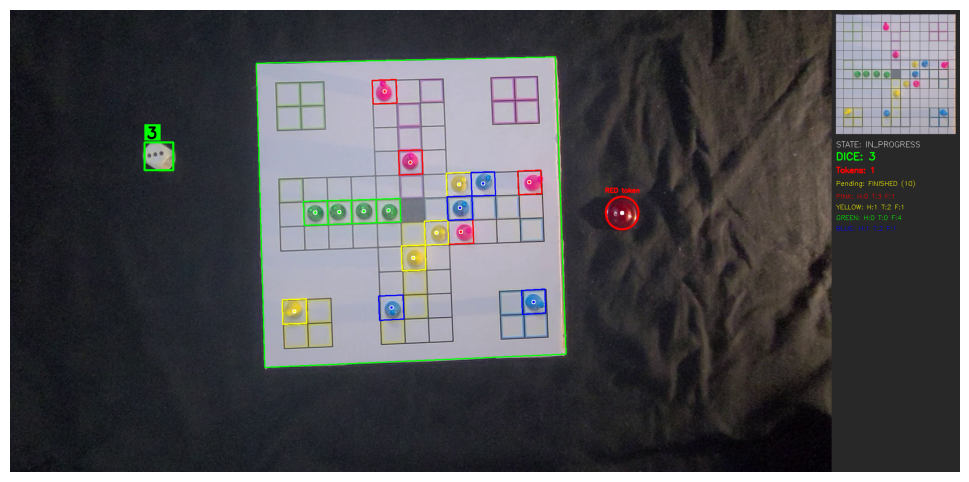


Done! Processed 5010 frames in 328.8s


In [224]:
INPUT_FOLDER = "videos"
OUTPUT_FOLDER = "output"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

if os.path.exists(INPUT_FOLDER):
    for file_name in os.listdir(INPUT_FOLDER):

        input_path = os.path.join(INPUT_FOLDER, file_name)

        if os.path.isfile(input_path):

            name_root, _ = os.path.splitext(file_name)

            output_name = f"output_{name_root}.mp4"
            output_path = os.path.join(OUTPUT_FOLDER, output_name)

            print(f"Processing: {file_name} -> {output_name}")

            events = process_video(input_path, output_path, display_interval=30)
else:
    print(f"Input directory not found: {INPUT_FOLDER}")